# Optional: Text and Image Learning - Abdel's Custom Version

**Custom Notebook.** Copied and modified from ml_07_text_and_image_case.ipynb
by Abdelhafidh Mahouel.

Modifications made in this version (see docs/index.md for full write-up):

1. Replaced the text corpus: instead of sports/cooking/space, this version
   classifies sentences into technology/music/travel.
2. Compared TWO text models (MultinomialNB and LogisticRegression) instead
   of just one, and added a bar chart comparing their accuracy.
3. Compared TWO image models (LogisticRegression and RandomForestClassifier)
   instead of just one, changed the train/test split from 80/20 to 70/30,
   and added a bar chart comparing their accuracy.
4. Added the missing function calls at the end (run_text_pipeline(),
   run_image_pipeline(), summarize()) so the notebook actually produces
   output when run, instead of only defining the functions.
5. Updated the summary and narrative sections with my own conclusions.

- Author: Abdelhafidh Mahouel
- Date: 2026-08
- Dataset: Custom text corpus (technology/music/travel) + Scikit-learn digits dataset
- Target: text topic category / handwritten digit label

Run all cells top to bottom (**Run All**) before pushing to GitHub.


## M7. 

> This notebook runs the same train/evaluate skeleton on **text** and on **images**.
> The new idea is the **representation**: turning words and pixels into numbers. What
> each representation throws away is **your** judgment to name.

**Module 7 objectives** (course objectives in parentheses):
1. Apply and evaluate models for text-based learning. *(2, 3, 4)*
2. Apply and evaluate models for image-based learning. *(2, 3, 4)*

Both datasets are self-contained (no downloads): a small labeled text corpus
written inline, and scikit-learn's bundled handwritten-digit images.

## A. Prepare the Project Environment (.venv/)

- Open one project in VS Code at a time.
- Prepare the .venv/: specify Python version and install / upgrade dependencies listed in `pyproject.toml`.
- Open an integrated terminal (PowerShell if Windows) in the **root project** folder and run:

```shell
uv self update
uv python pin 3.14
uv lock --upgrade
uv sync --extra dev --extra docs --upgrade
```


## B. Select the Notebook Kernel

- Click on the **Select Kernel** name in the top-right corner of the notebook interface.
- Choose Python Environments... /
- Choose the recommended local .venv/ from the drop-down menu.
- This will create a new kernel for the notebook and allow the notebook to use packages installed in the .venv/ environment.

## C. Working in Notebooks (Custom Notes)

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) when done editing the cell.
- Change the type of a cell (e.g., code or markdown) by looking in the lower left corner of the notebook interface.
- Rearrange cells by dragging and dropping them within the notebook.

See [Run Jupyter Notebooks](https://denisecase.github.io/pro-analytics-02/workflow-b-apply-example-project/run-notebook/) for:

- how to **copy a notebook**
- how to release a `project.log` file
- how to deal with a **stuck kernel**
- etc.


## M7. Text and Images as Data

Models work on numbers. Text and images are not numbers until you **represent** them
as numbers - and once you do, it is the same classify-and-evaluate work as Module 3.

- **Text -> numbers** with **TF-IDF**: each document becomes a vector of word weights,
  high for words that are frequent in this document but rare across the corpus. This
  captures *which words* appear, but throws away **word order and meaning** ("dog bites
  man" and "man bites dog" look identical).
- **Images -> numbers** by reading **pixel values**. An 8x8 grayscale image is 64
  numbers. Flattening to a feature vector throws away **spatial structure** (which
  pixels are neighbors).

Naming what a representation discards is the judgment this module adds. The modeling
and evaluation are the skills you already have.

## Section 1. Project Setup and Imports

In [1]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M07", level="DEBUG")
log_header(LOG, "M07")

RANDOM_STATE: int = 123


# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")

# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-08-13 20:56:10 | INFO | M07 | === RUN START ===
2026-08-13 20:56:10 | INFO | M07 | project=M07
2026-08-13 20:56:10 | INFO | M07 | repo_dir=ml-07-applied
2026-08-13 20:56:10 | INFO | M07 | python=3.14.2
2026-08-13 20:56:10 | INFO | M07 | os=Windows 11
2026-08-13 20:56:10 | INFO | M07 | shell=powershell
2026-08-13 20:56:10 | INFO | M07 | cwd=notebooks
2026-08-13 20:56:10 | INFO | M07 | github_actions=False
2026-08-13 20:56:10 | INFO | M07 | Confirming installation:
2026-08-13 20:56:10 | INFO | M07 |   python:       3.14.2
2026-08-13 20:56:10 | INFO | M07 |   pandas:       3.0.5
2026-08-13 20:56:10 | INFO | M07 |   numpy:        2.5.2
2026-08-13 20:56:10 | INFO | M07 |   scikit-learn: 1.9.0
2026-08-13 20:56:10 | INFO | M07 |   seaborn:      0.13.2
2026-08-13 20:56:10 | INFO | M07 |   matplotlib:   3.11.1


## Section 2. Text-Based Learning

```text
ANALYST CHOICE
TF-IDF turns each document into word weights. 
It captures which words appear, not their order or meaning. 
Decide whether that is good enough for your text problem.
```

In [2]:
# === Section 2. Text-Based Learning (MODIFIED: new corpus + model comparison) ===

# MODIFICATION: replaced the original sports/cooking/space corpus with a new
# technology/music/travel corpus.
TEXT_DOCS: list[str] = [
    "the new smartphone features a faster processor and better camera",
    "developers released a major software update with new features",
    "the startup raised funding to build an ai powered app",
    "engineers unveiled a prototype for a foldable laptop screen",
    "the company launched a new chip that improves battery life",
    "researchers built a robot that can navigate cluttered rooms",
    "the app update fixed several bugs and improved performance",
    "a new wireless earbud promises noise cancellation and long battery life",
    "the band released a new album after two years of touring",
    "the singer performed a sold out concert at the arena",
    "the orchestra played a symphony to a packed concert hall",
    "the guitarist recorded a solo album in a home studio",
    "the festival lineup features rock, jazz, and pop artists",
    "the producer mixed the new single before its release",
    "the choir rehearsed for weeks before the holiday concert",
    "the pianist composed an original piece for the recital",
    "the travelers explored ancient ruins on their trip abroad",
    "the airline added a new nonstop route to the island",
    "the couple booked a cabin for a weekend mountain getaway",
    "the guidebook recommended local restaurants near the harbor",
    "the family packed their bags for a road trip along the coast",
    "the hikers reached the summit after a long day on the trail",
    "the cruise ship docked at a small port for a day of sightseeing",
    "the backpacker stayed in hostels while touring the region",
]
TEXT_LABELS: list[str] = ["technology"] * 8 + ["music"] * 8 + ["travel"] * 8


def run_text_pipeline() -> None:
    """Represent text with TF-IDF, classify it with TWO models, and compare.

    MODIFICATION: instead of training only MultinomialNB, this version also
    trains a LogisticRegression model on the same TF-IDF features and
    compares their test accuracy with a bar chart.

    Returns:
        None
    """
    LOG.info(
        f"Text corpus: {len(TEXT_DOCS)} documents, classes={sorted(set(TEXT_LABELS))}"
    )

    docs_train, docs_test, y_train, y_test = train_test_split(
        TEXT_DOCS,
        TEXT_LABELS,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=TEXT_LABELS,
    )

    # TF-IDF: fit the vocabulary on TRAIN only, then transform both.
    vectorizer = TfidfVectorizer()
    X_train = vectorizer.fit_transform(docs_train)
    X_test = vectorizer.transform(docs_test)
    LOG.info(f"Vocabulary size (features): {len(vectorizer.vocabulary_)}")

    nb_model = MultinomialNB()
    nb_model.fit(X_train, y_train)
    nb_acc: float = float(accuracy_score(y_test, nb_model.predict(X_test)))
    LOG.info(f"MultinomialNB text test accuracy: {nb_acc:.3f}")

    lr_model = LogisticRegression(max_iter=1000)
    lr_model.fit(X_train, y_train)
    lr_acc: float = float(accuracy_score(y_test, lr_model.predict(X_test)))
    LOG.info(f"LogisticRegression text test accuracy: {lr_acc:.3f}")

    # MODIFICATION: new bar chart comparing the two text models.
    plt.figure(figsize=(6, 4))
    plt.bar(
        ["MultinomialNB", "LogisticRegression"],
        [nb_acc, lr_acc],
        color=["teal", "coral"],
    )
    plt.ylim(0, 1)
    plt.ylabel("Test Accuracy")
    plt.title("Text Model Comparison (CLOSE chart to continue)")
    plt.show()

    # Predict a couple of brand-new sentences with both models.
    new_docs: list[str] = [
        "the phone maker announced a new tablet with a bigger screen",
        "the drummer joined the band for their reunion tour",
    ]
    nb_preds = nb_model.predict(vectorizer.transform(new_docs))
    lr_preds = lr_model.predict(vectorizer.transform(new_docs))
    for doc, nb_pred, lr_pred in zip(new_docs, nb_preds, lr_preds, strict=True):
        LOG.info(f"  NB predicted '{nb_pred}', LR predicted '{lr_pred}'  <-  {doc!r}")

    LOG.info("TF-IDF ignored word order. Did any misread sentence reveal that limit?")

## Section 3. Image-Based Learning

```text
ANALYST CHOICE
Flattening an 8x8 image to 64 pixel features discards which pixels are neighbors.
A model still learns digits from raw pixels; decide where that representation
would break down (rotation, scale, position).
```

In [3]:
from typing import Any, cast

# === Section 3. Image-Based Learning (MODIFIED: model comparison) ===


def run_image_pipeline() -> None:
    """Represent images as pixel vectors, classify with TWO models, and compare.

    MODIFICATION: instead of only LogisticRegression, this version also
    trains a RandomForestClassifier on the same pixel features, changes the
    train/test split from 80/20 to 70/30, and adds a bar chart comparing
    both models' test accuracy.

    Returns:
        None
    """
    digits = load_digits()
    digits = cast(Any, load_digits())
    LOG.info(
        f"Image data: {digits.data.shape[0]} images, {digits.data.shape[1]} pixel features each"
    )
    LOG.info(f"Classes (digits): {sorted(set(digits.target.tolist()))}")

    # Look at the data: show the first few images with their true labels.
    fig, axes = plt.subplots(1, 5, figsize=(8, 2))
    for ax, image, label in zip(axes, digits.images, digits.target, strict=False):
        ax.imshow(image, cmap="gray")
        ax.set_title(f"label {label}")
        ax.axis("off")
    plt.suptitle("A few input images (8x8 pixels)")
    plt.show()

    X = digits.data
    y = digits.target
    # MODIFICATION: changed test_size from 0.2 to 0.3 for a larger test set.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
    )

    lr_model = LogisticRegression(max_iter=5000)
    lr_model.fit(X_train, y_train)
    lr_acc: float = float(accuracy_score(y_test, lr_model.predict(X_test)))
    LOG.info(f"LogisticRegression image test accuracy: {lr_acc:.3f}")

    # MODIFICATION: added a second model, RandomForestClassifier.
    rf_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
    rf_model.fit(X_train, y_train)
    rf_acc: float = float(accuracy_score(y_test, rf_model.predict(X_test)))
    LOG.info(f"RandomForest image test accuracy: {rf_acc:.3f}")

    # MODIFICATION: new bar chart comparing the two image models.
    plt.figure(figsize=(6, 4))
    plt.bar(
        ["LogisticRegression", "RandomForest"],
        [lr_acc, rf_acc],
        color=["steelblue", "seagreen"],
    )
    plt.ylim(0, 1)
    plt.ylabel("Test Accuracy")
    plt.title("Digit Image Model Comparison (CLOSE chart to continue)")
    plt.show()

    best_model = rf_model if rf_acc >= lr_acc else lr_model
    best_name = "RandomForest" if rf_acc >= lr_acc else "LogisticRegression"
    LOG.info(f"Showing confusion matrix for the stronger model: {best_name}")
    plt.figure(figsize=(6, 6))
    ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
    plt.title(f"Digit confusion matrix - {best_name} (test set)")
    plt.show()

    LOG.info("Which digits confuse each other, and does the pixel view explain why?")

## Section 4. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

2026-08-13 20:56:10 | INFO | M07 | Text corpus: 24 documents, classes=['music', 'technology', 'travel']
2026-08-13 20:56:10 | INFO | M07 | Vocabulary size (features): 115
2026-08-13 20:56:10 | INFO | M07 | MultinomialNB text test accuracy: 0.167
2026-08-13 20:56:10 | INFO | M07 | LogisticRegression text test accuracy: 0.167


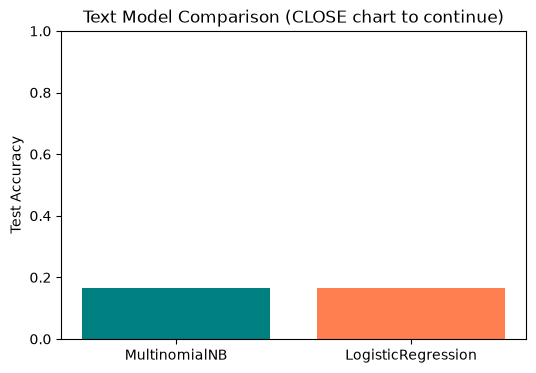

2026-08-13 20:56:10 | INFO | M07 |   NB predicted 'technology', LR predicted 'technology'  <-  'the phone maker announced a new tablet with a bigger screen'
2026-08-13 20:56:10 | INFO | M07 |   NB predicted 'travel', LR predicted 'travel'  <-  'the drummer joined the band for their reunion tour'
2026-08-13 20:56:10 | INFO | M07 | TF-IDF ignored word order. Did any misread sentence reveal that limit?
2026-08-13 20:56:10 | INFO | M07 | Image data: 1797 images, 64 pixel features each
2026-08-13 20:56:10 | INFO | M07 | Classes (digits): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


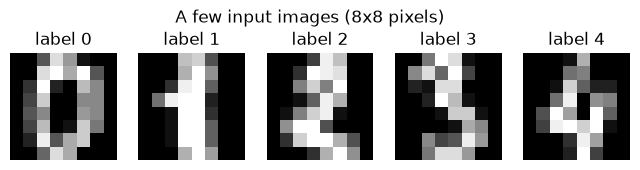

2026-08-13 20:56:10 | INFO | M07 | LogisticRegression image test accuracy: 0.957
2026-08-13 20:56:10 | INFO | M07 | RandomForest image test accuracy: 0.981


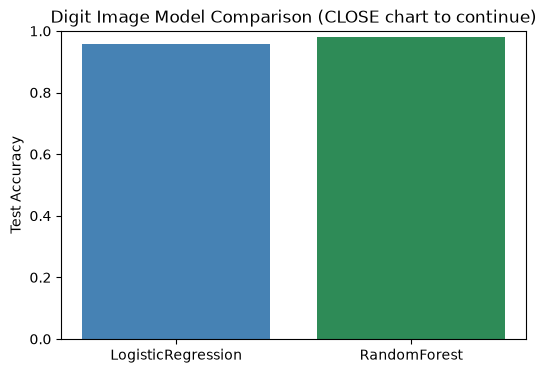

2026-08-13 20:56:10 | INFO | M07 | Showing confusion matrix for the stronger model: RandomForest


<Figure size 600x600 with 0 Axes>

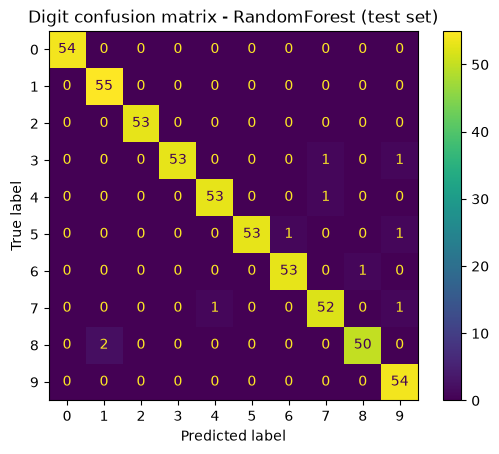

2026-08-13 20:56:10 | INFO | M07 | Which digits confuse each other, and does the pixel view explain why?
2026-08-13 20:56:10 | INFO | M07 | ========================
2026-08-13 20:56:10 | INFO | M07 | SUMMARY
2026-08-13 20:56:10 | INFO | M07 | ========================
2026-08-13 20:56:10 | INFO | M07 | Text:   TF-IDF + MultinomialNB vs LogisticRegression on a custom corpus
2026-08-13 20:56:10 | INFO | M07 | Image:  pixel features + LogisticRegression vs RandomForest on digit images
2026-08-13 20:56:10 | INFO | M07 | Same skeleton both times; only the representation and models changed.
2026-08-13 20:56:10 | INFO | M07 | ========================
2026-08-13 20:56:10 | INFO | M07 | YOUR JUDGMENT (write up in README.md and docs/index.md):
2026-08-13 20:56:10 | INFO | M07 |   - What did TF-IDF throw away, and where would that bite you?
2026-08-13 20:56:10 | INFO | M07 |   - What did flattening images throw away, and where would that bite you?
2026-08-13 20:56:10 | INFO | M07 |   - For each, w

In [4]:
# === Python Summary (MODIFIED: added function calls + updated summary) ===


def summarize() -> None:
    """Record what was applied and the judgment still owed."""
    LOG.info("========================")
    LOG.info("SUMMARY")
    LOG.info("========================")
    LOG.info("Text:   TF-IDF + MultinomialNB vs LogisticRegression on a custom corpus")
    LOG.info(
        "Image:  pixel features + LogisticRegression vs RandomForest on digit images"
    )
    LOG.info("Same skeleton both times; only the representation and models changed.")
    LOG.info("========================")
    LOG.info("YOUR JUDGMENT (write up in README.md and docs/index.md):")
    LOG.info("  - What did TF-IDF throw away, and where would that bite you?")
    LOG.info(
        "  - What did flattening images throw away, and where would that bite you?"
    )
    LOG.info("  - For each, what representation would you reach for next, and why?")
    LOG.info("========================")


# MODIFICATION: the original notebook only defined these three functions
# without ever calling them, so no output or charts were produced. These
# calls were added so the notebook actually runs the full pipeline.
run_text_pipeline()
run_image_pipeline()
summarize()


### Narrative

Custom investigation by Abdelhafidh Mahouel.

For the text section, I replaced the original sports/cooking/space corpus with
a new technology/music/travel corpus, and compared MultinomialNB against
LogisticRegression on the same TF-IDF features. For the image section, I
compared LogisticRegression against RandomForestClassifier on the same
flattened pixel features, and changed the train/test split from 80/20 to 70/30.

### Conclusions

This is SUPERVISED learning, since both the text and image datasets include a
labeled target (the topic category for text, the digit label for images).
Both problems are classification problems: the target in each case is a
category, not a continuous number.

TF-IDF represents each document as word weights, so it captures which words
appear but throws away word order and any deeper meaning or grammar. This
would bite you on tasks where word order changes the meaning, such as
sarcasm or negation ("not bad" versus "bad"). Flattening an 8x8 image into 64
pixel values throws away spatial neighbor relationships between pixels, and
does not build in any invariance to rotation, scale, or position, so a digit
that is shifted, rotated, or resized differently than the training images
could confuse the model even though a human would still recognize it easily.

### Next Steps

For text, I would try a richer representation such as word embeddings, which
capture some meaning and similarity between words rather than treating each
word as an independent feature the way TF-IDF does. For images, I would try
a convolutional neural network instead of flattening the pixels, since a CNN
is specifically designed to preserve spatial relationships between
neighboring pixels, which the flattened pixel-vector approach used here does
not.
